versão temporaria, markdowns apenas para não perder o raciocinio. reescrever em ingles

bibliotecas

In [45]:
import pandas as pd
import numpy as np
import sqlite3

colocando dados no db sql

In [46]:
con = sqlite3.connect('dataset.db')

customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')

customers.to_sql('customers', con, index=False, if_exists='replace')
orders.to_sql('orders', con, index=False, if_exists='replace')
items.to_sql('items', con, index=False, if_exists='replace')
products.to_sql('products', con, index=False, if_exists='replace')
geolocation.to_sql('geolocation', con, index=False, if_exists='replace')
translation.to_sql('translation', con, index=False, if_exists='replace')



71

vendo se foram inseridas corretamenet

In [52]:
tables = ['customers', 'orders', 'items', 'products', 'geolocation']

for table in tables:
    print(f"Table name: {table}")
    query = f"SELECT * FROM {table} LIMIT 5;"
    display(pd.read_sql_query(query, con))
    print()

Table name: customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



Table name: orders


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



Table name: items


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



Table name: products


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



Table name: geolocation


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


quais produtos geraram mais receita e qual categoria são

In [53]:
query = """
SELECT
    t.product_category_name_english,
    p.product_id,
    SUM(i.price + i.freight_value) AS total_revenue
FROM products AS p
INNER JOIN items AS i
    ON i.product_id = p.product_id
INNER JOIN translation AS t
    ON p.product_category_name = t.product_category_name
GROUP BY t.product_category_name_english, p.product_id
ORDER BY total_revenue DESC
LIMIT 10;
"""
pd.read_sql_query(query, con)



,product_category_name_english,product_id,total_revenue
0,health_beauty,bb50f2e236e5eea0100680137654686c,67606.10
1,computers_accessories,d1c427060a0f73f6b889a5c7c61f2ac4,60976.03
2,health_beauty,6cdd53843498f92890544667809f1595,59093.99
3,bed_bath_table,99a4788cb24856965c36a24e339b6058,51071.60
4,computers,d6160fb7873f184099d9bc95e30376af,50326.18
5,computers_accessories,3dd2a17168ec895c781a9191c1e95ad7,48212.22
6,furniture_decor,aca2eb7d00ea1a7b8ebd4e68314663af,44820.76
7,cool_stuff,5f504b3a1c75b73d6151be81eb05bdc9,41725.81
8,baby,25c38557cf793876c5abdd5931f922db,40311.95
9,watches_gifts,53b36df67ebb7c41585e8d54d6772e08,39957.93


receita por categoria

In [54]:
query = """
SELECT
    t.product_category_name_english,
    SUM(i.price + i.freight_value) AS category_revenue
FROM products AS p
INNER JOIN items AS i
    ON i.product_id = p.product_id
INNER JOIN translation AS t
    ON p.product_category_name = t.product_category_name
GROUP BY t.product_category_name_english
ORDER BY category_revenue DESC
LIMIT 10;
"""
pd.read_sql_query(query, con)

,product_category_name_english,category_revenue
0,health_beauty,1441248.07
1,watches_gifts,1305541.61
2,bed_bath_table,1241681.72
3,sports_leisure,1156656.48
4,computers_accessories,1059272.40
5,furniture_decor,902511.79
6,housewares,778397.77
7,cool_stuff,719329.95
8,auto,685384.32
9,garden_tools,584219.21


quantas vendas e quanto representa do total

In [55]:
query = """
SELECT
    t.product_category_name_english,
    COUNT(*) AS total_sales,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) AS percentage
FROM products AS p
INNER JOIN items AS i
    ON i.product_id = p.product_id
INNER JOIN translation AS t
    ON p.product_category_name = t.product_category_name
GROUP BY t.product_category_name_english
ORDER BY total_sales DESC
LIMIT 10;
"""
pd.read_sql_query(query, con)

,product_category_name_english,total_sales,percentage
0,bed_bath_table,11115,10.01
1,health_beauty,9670,8.71
2,sports_leisure,8641,7.78
3,furniture_decor,8334,7.51
4,computers_accessories,7827,7.05
5,housewares,6964,6.27
6,watches_gifts,5991,5.40
7,telephony,4545,4.09
8,garden_tools,4347,3.92
9,auto,4235,3.81


quantos consumidores e quanto representam  do total

In [56]:
query = """
SELECT
    customer_state,
    COUNT(*) AS costumers,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) AS pct
FROM customers
GROUP BY customer_state
ORDER BY costumers DESC
LIMIT 10
"""
pd.read_sql_query(query, con)

,customer_state,costumers,pct
0,SP,41746,41.98
1,RJ,12852,12.92
2,MG,11635,11.70
3,RS,5466,5.50
4,PR,5045,5.07
5,SC,3637,3.66
6,BA,3380,3.40
7,DF,2140,2.15
8,ES,2033,2.04
9,GO,2020,2.03


separar as compras por estado e data (yyyy-mm)

In [61]:
query = """
SELECT 
    c.customer_state,
    strftime('%Y', o.order_purchase_timestamp) AS year,
    strftime('%m', o.order_purchase_timestamp) AS month,
    COUNT(DISTINCT o.order_id) AS total_orders
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_state, year, month
ORDER BY c.customer_state, year, month;
"""
df_orders = pd.read_sql_query(query, con)

Como customers não são necessariamente únicos nessa base de dados, podemos contar o número de compras usando diretamente os customers e pegar o estado onde foi feita a compra

In [ ]:
df_orders['year_month'] = df_orders['year'] + '-' + df_orders['month']

pivot = df_orders.pivot_table(
    index='customer_state',
    columns='year_month',
    values='total_orders',
    fill_value=0
)
top_10_estados = pivot.sum(axis=1).nlargest(10).index
pivot_top = pivot.loc[top_10_estados]


pivot_top.head()

year_month,2016-09,2016-10,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,...,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08
customer_state,,,,,,,,,,,,,,,,,,,,,
SP,1.0,94.0,0.0,283.0,601.0,966.0,873.0,1363.0,1284.0,1543.0,...,2899.0,2295.0,2975.0,2632.0,2971.0,3002.0,3138.0,2738.0,2715.0,3164.0
RJ,0.0,40.0,0.0,91.0,230.0,370.0,325.0,466.0,399.0,547.0,...,1012.0,746.0,850.0,879.0,864.0,807.0,816.0,707.0,696.0,723.0
MG,0.0,35.0,0.0,102.0,241.0,343.0,266.0,412.0,356.0,435.0,...,922.0,669.0,846.0,790.0,856.0,778.0,751.0,714.0,644.0,700.0
RS,0.0,17.0,0.0,52.0,100.0,144.0,132.0,206.0,215.0,242.0,...,409.0,278.0,367.0,363.0,407.0,345.0,350.0,304.0,308.0,293.0
PR,0.0,19.0,1.0,62.0,110.0,121.0,112.0,206.0,167.0,195.0,...,365.0,260.0,371.0,335.0,369.0,381.0,308.0,306.0,314.0,327.0


gráfico de heatmap

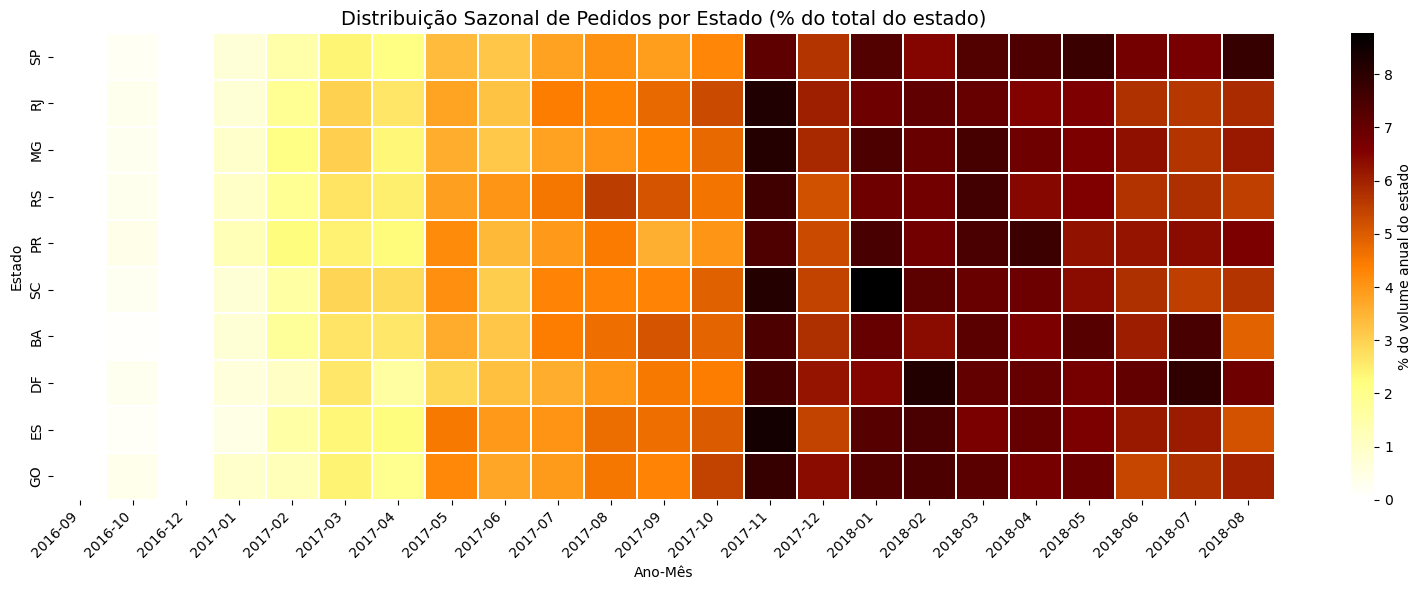

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# normaliza cada linha (estado) para somar 100%
pivot_normalizado = pivot_top.div(pivot_top.sum(axis=1), axis=0) * 100

plt.figure(figsize=(16, 6))
sns.heatmap(
    pivot_normalizado,
    cmap='afmhot_r',
    annot=False,
    linewidths=0.3,
    cbar_kws={'label': '% do volume anual do estado'}
)
plt.title('Distribuição Sazonal de Pedidos por Estado (% do total do estado)', fontsize=14)
plt.xlabel('Ano-Mês')
plt.ylabel('Estado')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('heatmap_sazonalidade_normalizado.png', dpi=150)
plt.show()

Notice the increase on November, which is when the black friday happens. Let's do a hypothesis test:

Mais complicado do que pensava, tem uma forte tendencia de crescimento com o tempo e a amostra de médias do mês de novembro é pequena, sem variância o teste não é robusto. Vamos fazer por regressão com dummy para o mês de Novembro e ver se a dummy é estatisticamente significante

In [ ]:
 query = """
SELECT
    strftime('%Y', order_purchase_timestamp) AS year,
    strftime('%m', order_purchase_timestamp) AS month,
    COUNT(*) AS total_orders
FROM orders
WHERE order_status = 'delivered'
GROUP BY year, month
ORDER BY year, month;
"""
df_mensal = pd.read_sql_query(query, con)

df_mensal['t'] = range(len(df_mensal))
df_mensal['is_november'] = (df_mensal['month'] == '11').astype(int)

In [79]:
import statsmodels.api as sm

# Variável dependente: total_orders
y = df_mensal['total_orders']
# Variáveis independentes: tendência linear + dummy novembro
X = df_mensal[['t', 'is_november']]
X = sm.add_constant(X)  # adiciona o intercepto

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           total_orders   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     99.51
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           4.03e-11
Time:                        17:07:34   Log-Likelihood:                -184.38
No. Observations:                  23   AIC:                             374.8
Df Residuals:                      20   BIC:                             378.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         400.1819    318.009      1.258      

deu certo, resultados significativos, tendencia de crescimento com o tempo e p-valor abaixo de 0.05 da dummy, então o efeito de novembro é significante

Outro problema interessante: entrega adiantada -> consumidor recorrente?

H0: o número médio de pedidos feitos por clientes que tiveram pelo menos uma entrega adiantada é igual ao daqueles que nunca receberam antes do prazo.
H1:clientes com ao menos uma entrega adiantada fazem, em média, mais pedidos.

query enorme, tentar otimizar antes de publicar

In [83]:
query = """
WITH delivery_performance AS (
    SELECT
        o.customer_id,
        c.customer_unique_id,
        o.order_id,
        CASE
            WHEN julianday(o.order_delivered_customer_date) < julianday(o.order_estimated_delivery_date) - 1
                THEN 'early'
            WHEN julianday(o.order_delivered_customer_date) BETWEEN julianday(o.order_estimated_delivery_date) - 1 
                                                               AND julianday(o.order_estimated_delivery_date) + 1 
                THEN 'on_time'
            ELSE 'late'
        END AS delivery_status
    FROM orders o
    INNER JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
),
customer_profile AS (
    SELECT
        customer_unique_id,
        MAX(CASE WHEN delivery_status = 'early' THEN 1 ELSE 0 END) AS has_early
    FROM delivery_performance
    GROUP BY customer_unique_id
),
customer_orders AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS total_orders
    FROM orders o
    INNER JOIN customers c ON o.customer_id = c.customer_id
    GROUP BY c.customer_unique_id
),
merged AS (
    SELECT
        co.customer_unique_id,
        cp.has_early,
        co.total_orders
    FROM customer_orders co
    INNER JOIN customer_profile cp ON co.customer_unique_id = cp.customer_unique_id
)
SELECT
    has_early,
    COUNT(*) AS n,
    AVG(total_orders) AS mean_orders,
    (SUM(total_orders * total_orders) - (SUM(total_orders) * SUM(total_orders)) / COUNT(*)) / (COUNT(*) - 1) AS var_orders
FROM merged
GROUP BY has_early;
"""
df_stats = pd.read_sql_query(query, con)
print(df_stats)

   has_early      n  mean_orders  var_orders
0          0   8845     1.008932           0
1          1  84505     1.038412           0


A média dos dois grupos é quase 1, isso é estranho, quer dizer que ninguem foi comprador recorrente? Será que as lojas aumentam artificialmente o prazo para fazerem mais entregas "antes do prazo"?

H0 = a diferença entre o prazo de entrega e a data da entrega é 0 (quer dizer que o prazo está, em média, corretamente estimados)
H1= a diferença é maior que zero (quer dizer que, em média, estimam prazos maiores do que os reais)

In [85]:
query_folga = """
SELECT
    order_id,
    julianday(order_estimated_delivery_date) - julianday(order_delivered_customer_date) AS dias_folga
FROM orders
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL
  AND order_estimated_delivery_date IS NOT NULL;
"""
df_folga = pd.read_sql_query(query_folga, con)
print(df_folga.head())

                           order_id  dias_folga
0  e481f51cbdc54678b7cc49136f2d6af7    7.107488
1  53cdb2fc8bc7dce0b6741e2150273451    5.355729
2  47770eb9100c2d0c44946d9cf07ec65d   17.245498
3  949d5b44dbf5de918fe9c16f97b45f8a   12.980069
4  ad21c59c0840e6cb83a9ceb5573f8159    9.238171


In [86]:
from scipy import stats

dias = df_folga['dias_folga']
t_stat, p_bilateral = stats.ttest_1samp(dias, popmean=0)

# Converter para unilateral (H1: média > 0)
if t_stat > 0:
    p_unilateral = p_bilateral / 2
else:
    p_unilateral = 1.0

print(f"Média de dias de folga: {dias.mean():.2f}")
print(f"Mediana: {dias.median():.2f}")
print(f"Desvio padrão: {dias.std():.2f}")
print(f"t = {t_stat:.4f}, p-value (unilateral) = {p_unilateral:.6f}")

Média de dias de folga: 11.18
Mediana: 11.95
Desvio padrão: 10.18
t = 340.9036, p-value (unilateral) = 0.000000


deixam 11 dias a mais, em média, com p-valor baixissimo, podemos concluir que inflam os prazos com toda certeza, é estatísticamente impossível que isso seja aleatório

vamos fazer gráfico para mostrar quão longe do zero esta essa média

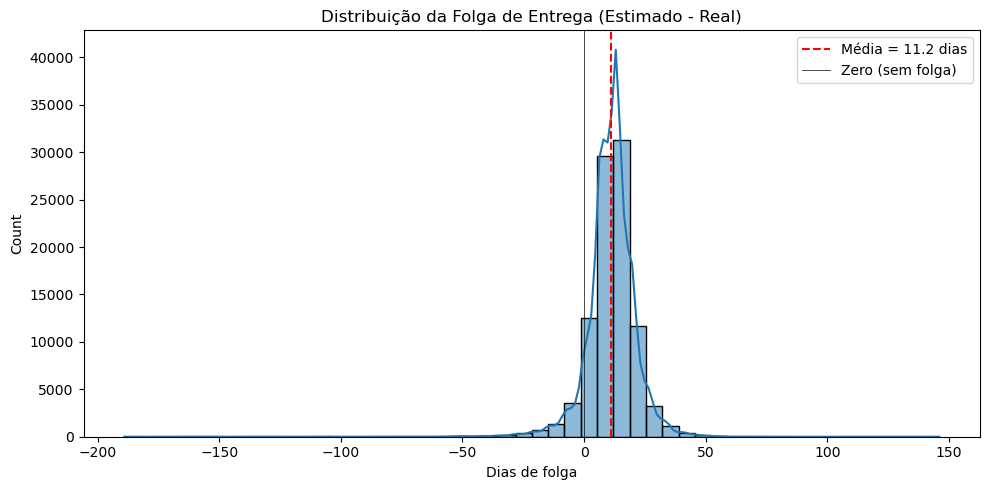

In [88]:
plt.figure(figsize=(10,5))
sns.histplot(dias, bins=50, kde=True)
plt.axvline(dias.mean(), color='red', linestyle='--', label=f'Média = {dias.mean():.1f} dias')
plt.axvline(0, color='black', linestyle='-', linewidth=0.5, label='Zero (sem folga)')
plt.title('Distribuição da Folga de Entrega (Estimado - Real)')
plt.xlabel('Dias de folga')
plt.legend()
plt.tight_layout()
plt.show()

muitos outliers estão inclusos, vamos eliminar

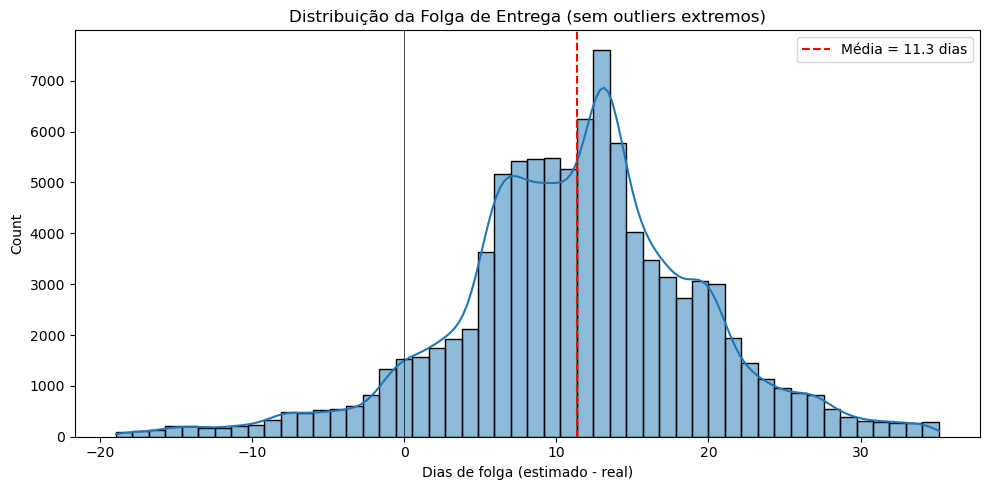

In [91]:
lower = dias.quantile(0.01)
upper = dias.quantile(0.99)
dias_filtrado = dias[(dias >= lower) & (dias <= upper)]
plt.figure(figsize=(10,5))
sns.histplot(dias_filtrado, bins=50, kde=True)
plt.axvline(dias_filtrado.mean(), color='red', linestyle='--', label=f'Média = {dias_filtrado.mean():.1f} dias')
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Distribuição da Folga de Entrega (sem outliers extremos)')
plt.xlabel('Dias de folga (estimado - real)')
plt.legend()
plt.tight_layout()
plt.show()

ainda falta formatação, fluidez, contar história, traduzir para ingles e concluir